这个文档是由B720s的数据得到Br

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS
from astropy.wcs.utils import pixel_to_skycoord

In [ ]:
import numpy as np
import astropy.units as u
from astropy.wcs.utils import pixel_to_skycoord

def hmi_vector_to_helio(B_map, inc_map, azi_map):

    B = B_map.data
    gamma = np.deg2rad(inc_map.data)
    phi = np.deg2rad(azi_map.data)

    # HMI vector components (CCD frame)
    Bzeta = B*np.cos(gamma)
    Bxi   = B*np.sin(gamma)*np.sin(phi)
    Beta  =  B*np.sin(gamma)*np.cos(phi)

    ny, nx = B.shape
    y, x = np.mgrid[0:ny,0:nx]

    coords = pixel_to_skycoord(x, y, B_map.wcs)

    Tx = coords.Tx.to(u.rad).value
    Ty = coords.Ty.to(u.rad).value

    rho = np.sqrt(Tx**2 + Ty**2)

    B0 = B_map.observer_coordinate.lat.to(u.rad).value
    P  = B_map.meta['crota2'] * np.pi/180

    sin_rho = np.sin(rho)
    cos_rho = np.cos(rho)

    sinP = np.sin(P)
    cosP = np.cos(P)

    sinB0 = np.sin(B0)
    cosB0 = np.cos(B0)

    # rotation matrix
    k11 = cos_rho
    k12 = -sin_rho*sinP
    k13 = sin_rho*cosP

    k21 = sin_rho*sinB0
    k22 = cos_rho*cosP + sin_rho*sinP*cosB0
    k23 = cos_rho*sinP - sin_rho*cosP*cosB0

    k31 = -sin_rho*cosB0
    k32 = cos_rho*cosP*sinB0 - sin_rho*sinP
    k33 = cos_rho*sinP*sinB0 + sin_rho*cosP

    Bphi   = k11*Bxi + k12*Beta + k13*Bzeta
    Btheta = k21*Bxi + k22*Beta + k23*Bzeta
    Br     = k31*Bxi + k32*Beta + k33*Bzeta

    mu = np.cos(rho)
    Br[mu < 0.1] = np.nan

    return Br, Btheta, Bphi

In [2]:
hmi_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_720s\\'
B_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.field.fits')
inc_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.inclination.fits')
azi_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.azimuth.fits')

In [15]:
Br,Btheta,Bphi=hmi_vector_to_helio(B_map, inc_map, azi_map)
Br_map=sunpy.map.Map(Br, B_map.meta)
Br_map=Br_map.rotate()

In [17]:
print(B_map.meta['crota2'])

180.013519


In [19]:
print(B_map.meta['crota2'])
print(B_map.meta['CRLT_OBS'])

180.013519
1.50528705


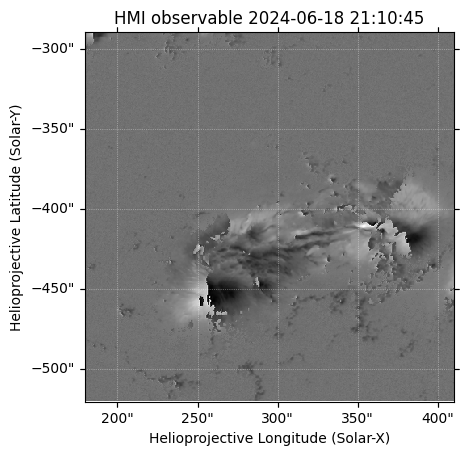

In [16]:
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=Br_map.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=Br_map.coordinate_frame)

sub_map=Br_map.submap(bottom_left,top_right=top_right)
sub_map.plot()

In [25]:
d= readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI4\bxyz_map.sav')
# IDL 变量名在 Python 里通常会变成小写
print(d.keys())   # 先看实际键名

mapbx = d["mapbx"][0][0]
mapby = d["mapby"][0][0]
mapbz = d["mapbz"][0][0]

print(type(mapbx), mapbx.shape)

dict_keys(['mapbx', 'mapby', 'mapbz'])
<class 'numpy.ndarray'> (4096, 4096)


In [24]:
hmi_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_720s\\'
B_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.field.fits').rotate()
#p    = np.deg2rad(B_map.meta['CROTA2'])
inc_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.inclination.fits').rotate()
azi_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.azimuth.fits').rotate()

d= readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI4\bxyz_map.sav')
# IDL 变量名在 Python 里通常会变成小写
print(d.keys())   # 先看实际键名

mapbx = d["mapbx"][0][0]
mapby = d["mapby"][0][0]
mapbz = d["mapbz"][0][0]

dict_keys(['mapbx', 'mapby', 'mapbz'])


In [ ]:
# 1 获取 header 参数
phi0 = B_map.observer_coordinate.lon.to(u.rad).value
b    = B_map.observer_coordinate.lat.to(u.rad).value
# WCS rotation matrix
pc = B_map.wcs.wcs.pc

# P-angle（弧度）
p = np.arctan2(pc[0,1], pc[0,0])
# 2 像素坐标
ny,nx = B_map.data.shape
y,x = np.mgrid[0:ny,0:nx]

# 3 skycoord
coords = pixel_to_skycoord(x,y,B_map.wcs)

# 4 heliographic
hg = coords.transform_to(frames.HeliographicStonyhurst)

phi = hg.lon.to(u.rad).value
lam = hg.lat.to(u.rad).value

In [35]:
print(B_map.data.shape)

(4098, 4098)


In [26]:
import numpy as np

# WCS rotation matrix
pc = B_map.wcs.wcs.pc

# P-angle（弧度）
p = np.arctan2(pc[0,1], pc[0,0])
print(np.rad2deg(p))

-1.8943907412185183e-18


In [28]:
import numpy as np

dphi = phi - phi0

k11 = np.cos(lam)*(np.sin(b)*np.sin(p)*np.cos(dphi) + np.cos(p)*np.sin(dphi)) \
      - np.sin(lam)*(np.cos(b)*np.sin(p))

k12 = -np.cos(lam)*(np.sin(b)*np.cos(p)*np.cos(dphi) - np.sin(p)*np.sin(dphi)) \
      + np.sin(lam)*(np.cos(b)*np.cos(p))

k13 = np.cos(lam)*np.cos(b)*np.cos(dphi) + np.sin(lam)*np.sin(b)


k21 = np.sin(lam)*(np.sin(b)*np.sin(p)*np.cos(dphi) + np.cos(p)*np.sin(dphi)) \
      + np.cos(lam)*(np.cos(b)*np.sin(p))

k22 = -np.sin(lam)*(np.sin(b)*np.cos(p)*np.cos(dphi) - np.sin(p)*np.sin(dphi)) \
      - np.cos(lam)*(np.cos(b)*np.cos(p))

k23 = np.sin(lam)*np.cos(b)*np.cos(dphi) - np.cos(lam)*np.sin(b)


k31 = -np.sin(b)*np.sin(p)*np.sin(dphi) + np.cos(p)*np.cos(dphi)

k32 =  np.sin(b)*np.cos(p)*np.sin(dphi) + np.sin(p)*np.cos(dphi)

k33 = -np.cos(b)*np.sin(dphi)

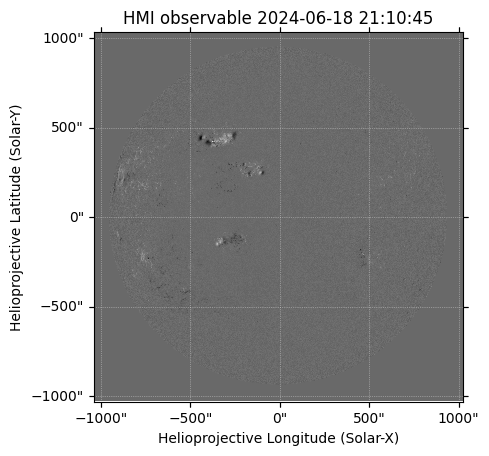

In [6]:
B_map_rot=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.field.fits').rotate()
Bx_map_rot=sunpy.map.Map(mapbx,B_map.meta).rotate()
Bx_map_rot.plot()

In [30]:
del Br,Btheta,Bphi

In [33]:
print(k11.shape)

(4098, 4098)


In [31]:
Bx=mapbx
By=mapby
Bz=mapbz

Br =( k11*Bx + k12*By + k13*Bz)
Btheta = k21*Bx + k22*By + k23*Bz
Bphi = k31*Bx + k32*By + k33*Bz

ValueError: operands could not be broadcast together with shapes (4098,4098) (4096,4096) 

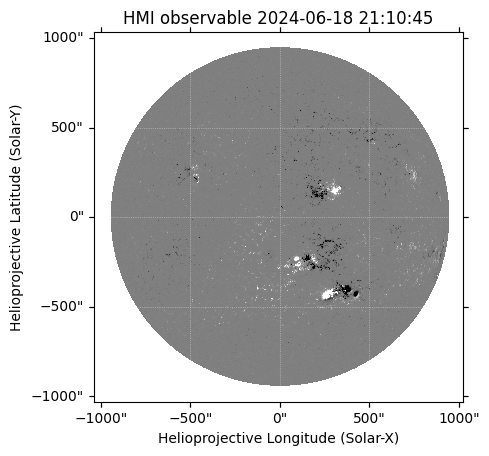

In [23]:
im=Bz_map.plot()
im.set_clim(-600,600)

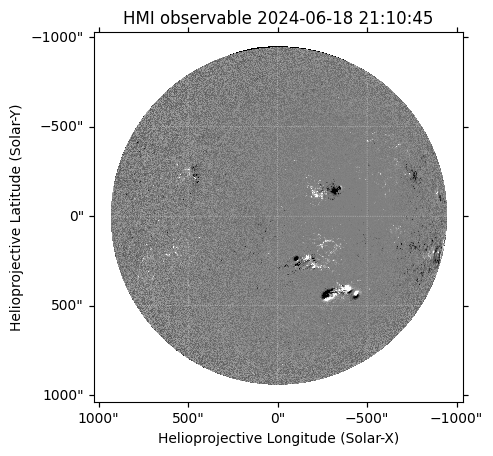

In [19]:
Br_map=sunpy.map.Map(Br, B_map.meta)
im=Br_map.plot()
im.set_clim(-600,600)

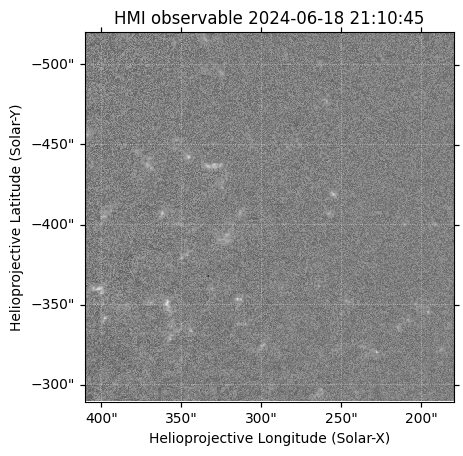

In [ ]:

#Br_map=Br_map.rotate()
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=Br_map.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=Br_map.coordinate_frame)

sub_map=Br_map.submap(bottom_left,top_right=top_right)
im=sub_map.plot()
im.set_clim(-600,600)

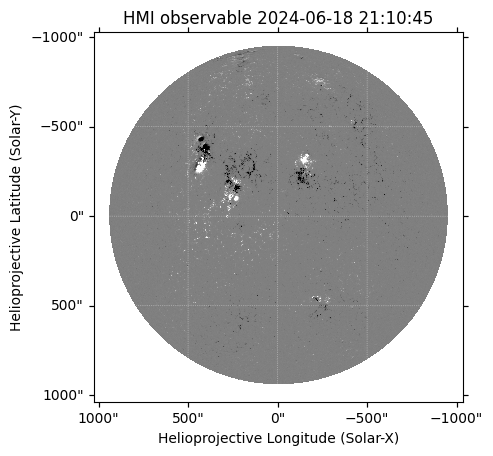

In [19]:
Bz_map=sunpy.map.Map(Bz.T, B_map.meta)
im=Bz_map.plot()
im.set_clim(-600,600)

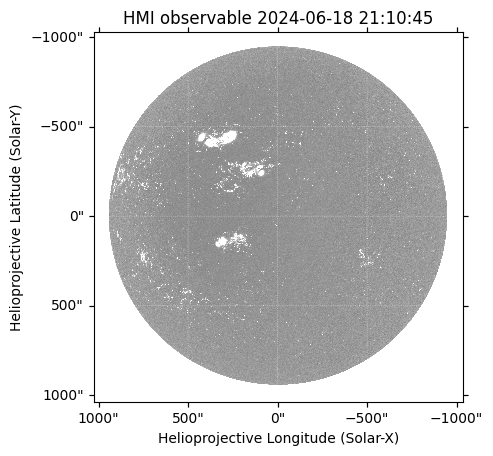

In [7]:
B_field=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI4\hmi.B_720s.20240618_211200_TAI.field.fits')
imB=B_field.plot()
imB.set_clim(-600,600)

---------------------------------------------------------------IDL-----------------------------------------------------

In [3]:
hmi_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_720s\\'
B_map   = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.field.fits')
inc_map = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.inclination.fits')
azi_map = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.azimuth.fits')
dis_map = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.disambig.fits')

B   = B_map.data
inc = inc_map.data   # degree
azi = azi_map.data   # degree
dis = dis_map.data

# === 2. 处理 180° ambiguity ===
# IDL: if disambig > 3 → azimuth + 180°
mask = dis > 3
azi = azi.copy()
azi[mask] += 180.0

# === 3. 角度转弧度 ===
inc_rad = np.deg2rad(inc)
azi_rad = np.deg2rad(azi + 270.0)   # ⚠️ 非常关键（IDL中的定义）

# === 4. 计算 Bxyz（未 rotate）===
Bz = B * np.cos(inc_rad)
Bx = B * np.sin(inc_rad) * np.cos(azi_rad)
By = B * np.sin(inc_rad) * np.sin(azi_rad)

# === 5. IDL rotate(...,2) → 180°翻转 ===
Bz = np.rot90(Bz, 2)
Bx = np.rot90(Bx, 2)
By = np.rot90(By, 2)

# === 6. 处理异常值（对应 IDL）===
mask_bad = Bx <= -10000.0
Bx[mask_bad] = 0.0
By[mask_bad] = 0.0

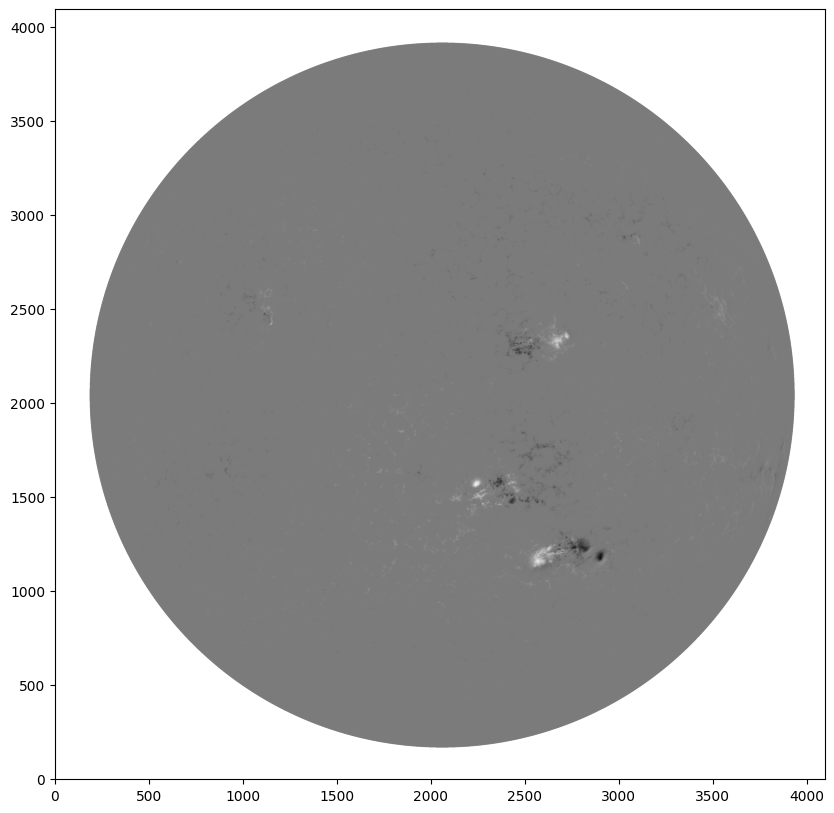

In [5]:
plt.figure(figsize=(10,10))
plt.imshow(Bz,origin='lower',cmap='gray')

In [8]:
phi=0.2*np.pi
phi = phi + np.pi

phi = np.mod(phi + np.pi, 2*np.pi)
print(phi)

0.6283185307179586
